In [1]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot  as plt
import cv2

import tensorflow as tf 
from tensorflow.keras import applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D


2026-01-07 01:18:39.317979: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767748719.331496      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767748719.335758      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 01:18:39.353977: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
train_csv_path = "../input/cassava-leaf-disease-classification/train.csv"
label_json_path = "../input/cassava-leaf-disease-classification/label_num_to_disease_map.json"
images_dir_path = "../input/cassava-leaf-disease-classification/train_images"


In [3]:
train_csv = pd.read_csv(train_csv_path)
train_csv['label'] = train_csv['label'].astype('string')

label_class = pd.read_json(label_json_path, orient='index')
label_class = label_class.values.flatten().tolist()


In [4]:
print("Label names :")
for i, label in enumerate(label_class):
    print(f" {i}. {label}")


Label names :
 0. Cassava Bacterial Blight (CBB)
 1. Cassava Brown Streak Disease (CBSD)
 2. Cassava Green Mottle (CGM)
 3. Cassava Mosaic Disease (CMD)
 4. Healthy


In [5]:
train_csv.head()


,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [6]:
BATCH_SIZE = 24
IMG_SIZE = 320


In [7]:
# Data agumentation and pre-processing using tensorflow
train_gen = ImageDataGenerator(
                                rotation_range=270,
                                width_shift_range=0.2,
                                height_shift_range=0.2,
                                brightness_range=[0.1,0.9],
                                shear_range=25,
                                zoom_range=0.3,
                                channel_shift_range=0.1,
                                horizontal_flip=True,
                                vertical_flip=True,
                                rescale=1/255,
                                validation_split=0.2
                               )
                                    
    
valid_gen = ImageDataGenerator(rescale=1/255,
                               validation_split = 0.2
                              )


In [8]:
train_generator = train_gen.flow_from_dataframe(
                            dataframe=train_csv,
                            directory = images_dir_path,
                            x_col = "image_id",
                            y_col = "label",
                            target_size = (IMG_SIZE, IMG_SIZE),
                            class_mode = "categorical",
                            batch_size = BATCH_SIZE,
                            shuffle = True,
                            subset = "training",

)

valid_generator = valid_gen.flow_from_dataframe(
                            dataframe=train_csv,
                            directory = images_dir_path,
                            x_col = "image_id",
                            y_col = "label",
                            target_size = (IMG_SIZE, IMG_SIZE),
                            class_mode = "categorical",
                            batch_size = BATCH_SIZE,
                            shuffle = False,
                            subset = "validation"
)


Found 14977 validated image filenames belonging to 5 classes.
Found 3744 validated image filenames belonging to 5 classes.


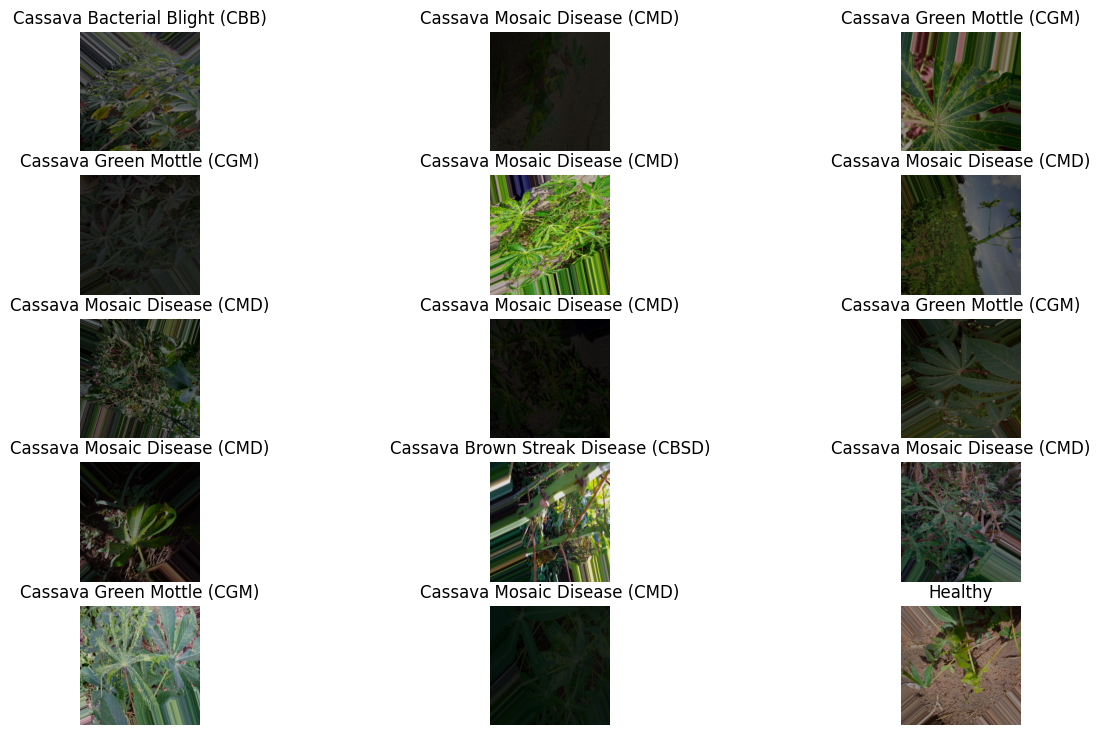

In [9]:
batch = next(train_generator)
images = batch[0]
labels = batch[1]

plt.figure(figsize=(15,9))
for i, (img, label) in enumerate(zip(images, labels)):
    plt.subplot(5,3, i%15 +1)
    plt.axis('off')
    plt.imshow(img)
    plt.title(label_class[np.argmax(label)])
    
    if i==15:
        break


In [10]:
# Loading the InceptionResNetV2 architecture with imagenet weights as base
base = applications.InceptionResNetV2(include_top=False, weights='imagenet',input_shape=[IMG_SIZE,IMG_SIZE,3])
#base.summary()


2026-01-07 01:18:49.834098: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767748729.834539      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 40095 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, compute capability: 8.6


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [11]:
model = tf.keras.Sequential()
model.add(base)
model.add(BatchNormalization(axis=-1))
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dense(5, activation='softmax'))

model.compile(loss=tf.keras.losses.CategoricalCrossentropy(), optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), metrics=['acc', tf.keras.metrics.TruePositives(name='tp')])
#model.summary()


In [12]:
# #Setting a callbacks for model during the training
def scheduler(epoch, lr):
    if epoch >3 and epoch%2==0:
        return lr/1.25
    else:
        return lr

# A callback to save the model
callback0 = tf.keras.callbacks.ModelCheckpoint("./CasavaLeafDiseaseModel.h5", 
                                               monitor='val_loss',save_best_only=True)

# A callback to reduce the learning rate with increase in epoch
callback1 = tf.keras.callbacks.LearningRateScheduler(scheduler)


In [13]:
# Loading the saved model
try:
    model = tf.keras.models.load_model("../input/casavaleafdiseasemodel-tf/CasavaLeafDiseaseModel_epoch_12_acc_85.h5")
except:
    print("No saved model. So Train the model !")
    
#his = model.fit(train_generator, validation_data=valid_generator, epochs=8, callbacks=[callback0, callback1])


No saved model. So Train the model !


In [14]:
#stats = pd.DataFrame(his.history)


In [15]:
test_img_path = "../input/cassava-leaf-disease-classification/test_images/2216849948.jpg"

img = cv2.imread(test_img_path)
resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).reshape(-1, IMG_SIZE, IMG_SIZE, 3)/255

plt.figure(figsize=(8,4))
plt.title("TEST IMAGE")
plt.imshow(resized_img[0])


[ WARN:0@16.256] global loadsave.cpp:275 findDecoder imread_('../input/cassava-leaf-disease-classification/test_images/2216849948.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [16]:
preds = []
ss = pd.read_csv('../input/cassava-leaf-disease-classification/sample_submission.csv')

for image in ss.image_id:
    img = tf.keras.preprocessing.image.load_img('../input/cassava-leaf-disease-classification/test_images/' + image)
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = tf.keras.preprocessing.image.smart_resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.reshape(img, (-1, IMG_SIZE, IMG_SIZE, 3))
    prediction = model.predict(img/255)
    preds.append(np.argmax(prediction))

my_submission = pd.DataFrame({'image_id': ss.image_id, 'label': preds})
my_submission.to_csv('submission.csv', index=False) 


I0000 00:00:1767748738.812609      70 service.cc:148] XLA service 0x7f79d40c8820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767748738.812640      70 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-07 01:18:58.965405: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767748740.141806      70 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


I0000 00:00:1767748742.926730      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

In [17]:
# Submission file ouput
print("Submission File: \n---------------\n")
print(my_submission.head()) # Predicted Output


Submission File: 
---------------

         image_id  label
0  1234294272.jpg      1
1  1234332763.jpg      4
2  1234375577.jpg      4
3  1234555380.jpg      4
4  1234571117.jpg      4
